In [56]:
import pandas as pd
import glob
import os

# Current working folder
print("Current folder:")
print(os.getcwd())

# Find all Excel files containing Retail
files = glob.glob("*Retail*.xlsx") + glob.glob("*Retail*.xls")

print("\nRetail Excel files found:")
for f in files:
    print(f)

if not files:
    print("\n❌ Retail Excel file nahi mili.")
else:
    df = pd.read_excel(files[0])
    print("\n✅ Dataset loaded successfully:")
    print(files[0])
    print("\nShape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())


Current folder:
c:\Users\mvlui\Desktop\AIPRACTICALNIDHI

Retail Excel files found:
Retail and wherehouse Sale (1).xlsx

✅ Dataset loaded successfully:
Retail and wherehouse Sale (1).xlsx

Shape: (30000, 9)

Columns:
['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import glob
files = glob.glob("*Retail*.xlsx") + glob.glob("*Retail*.xls")
df = pd.read_excel(files[0])
print("Dataset Loaded Successfully!")
print("File:", files[0])
d = df[
    ["ITEM TYPE", "YEAR", "RETAIL SALES"]
].dropna()

print("\nDataset Shape:", d.shape)
print("\n14. FACTORS")
print("Factor 1 : ITEM TYPE")
print("Factor 2 : YEAR")
print("Response : RETAIL SALES")
avg_sales = d.groupby(
    ["ITEM TYPE", "YEAR"]
)["RETAIL SALES"].mean().reset_index()

print("\n15. Average Retail Sales:")
print(avg_sales)
-=

Dataset Loaded Successfully!
File: Retail and wherehouse Sale (1).xlsx

Dataset Shape: (29999, 3)

14. FACTORS
Factor 1 : ITEM TYPE
Factor 2 : YEAR
Response : RETAIL SALES

15. Average Retail Sales:
      ITEM TYPE  YEAR  RETAIL SALES
0          BEER  2020     14.118748
1       DUNNAGE  2020      0.000000
2          KEGS  2020      0.000000
3        LIQUOR  2020     13.635171
4   NON-ALCOHOL  2020     31.742419
5           REF  2020      5.783750
6  STR_SUPPLIES  2020      5.485714
7          WINE  2020      3.195334


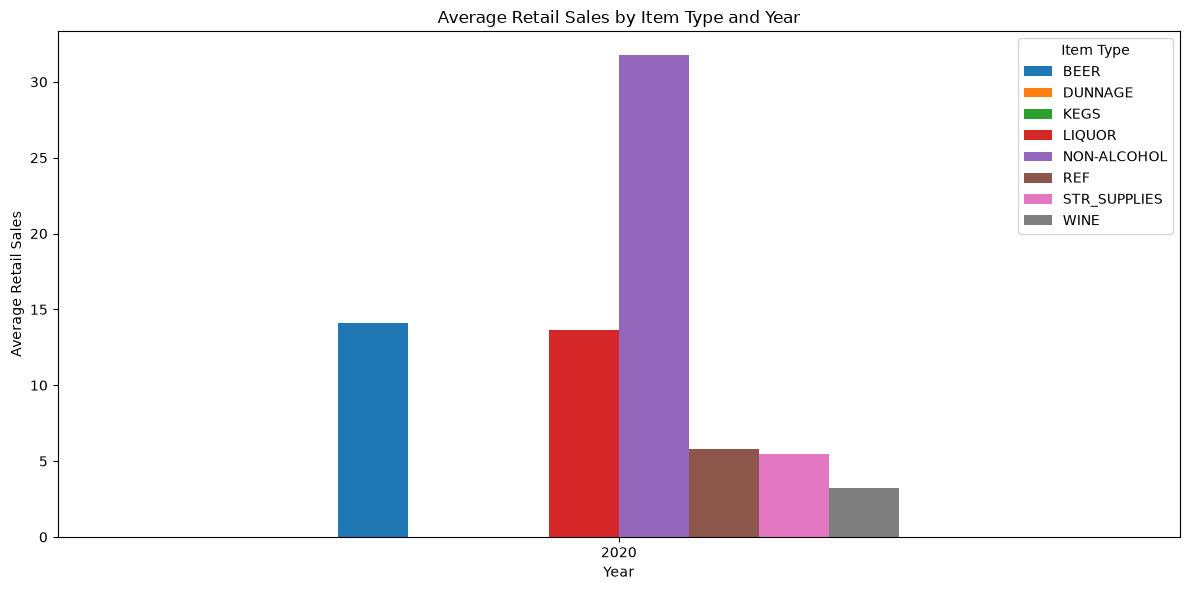

In [60]:
pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Retail Sales by Item Type and Year")
plt.xlabel("Year")
plt.ylabel("Average Retail Sales")
plt.xticks(rotation=0)
plt.legend(title="Item Type")
plt.tight_layout()
plt.show()

In [61]:
item_effect = d.groupby(
    "ITEM TYPE"
)["RETAIL SALES"].mean().sort_values(
    ascending=False
)
print("\n17. Main Effect of ITEM TYPE:")
print(item_effect)


17. Main Effect of ITEM TYPE:
ITEM TYPE
NON-ALCOHOL     31.742419
BEER            14.118748
LIQUOR          13.635171
REF              5.783750
STR_SUPPLIES     5.485714
WINE             3.195334
KEGS             0.000000
DUNNAGE          0.000000
Name: RETAIL SALES, dtype: float64


In [62]:
year_effect = d.groupby(
    "YEAR"
)["RETAIL SALES"].mean()

print("\n18. Main Effect of YEAR:")
print(year_effect)
print(
    "\nNumber of Years:",
    d["YEAR"].nunique()
)


18. Main Effect of YEAR:
YEAR
2020    6.939796
Name: RETAIL SALES, dtype: float64

Number of Years: 1


In [63]:

print("\n19. Interaction Effect")
if d["YEAR"].nunique() < 2:

    print(
        "ITEM TYPE × YEAR interaction cannot be "
        "calculated because only one YEAR is present."
    )

else:

    print(
        "ITEM TYPE × YEAR interaction can be tested."
    )
print("\n20. FACTORIAL ANOVA")

if d["YEAR"].nunique() < 2:

    print(
        "Factorial ANOVA cannot be performed because "
        "YEAR contains only one level."
    )

else:

    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm

    model = ols(
        "Q('RETAIL SALES') ~ "
        "C(Q('ITEM TYPE')) * C(Q('YEAR'))",
        data=d
    ).fit()

    anova_result = anova_lm(
        model,
        typ=2
    )
    print(anova_result)
print("\n21. STATISTICAL RESULTS")

# ITEM TYPE ANOVA
groups = [
    group["RETAIL SALES"].values
    for name, group in d.groupby("ITEM TYPE")
]

F, p = f_oneway(*groups)
print("\nITEM TYPE")
print("F-statistic =", round(F, 4))
print("p-value =", round(p, 6))
if d["YEAR"].nunique() < 2:

    print("\nYEAR")
    print("p-value = Not available")

    print("\nITEM TYPE × YEAR")
    print("p-value = Not available")
print("\n22. SIGNIFICANCE")

if p < 0.05:

    print(
        "ITEM TYPE -> SIGNIFICANT"
    )

else:

    print(
        "ITEM TYPE -> NOT SIGNIFICANT"
    )


if d["YEAR"].nunique() < 2:

    print(
        "YEAR -> Cannot be tested"
    )

    print(
        "ITEM TYPE × YEAR -> Cannot be tested"
    )
print("\n23. FINAL BUSINESS CONCLUSION")
if p < 0.05:

    print(
        "Retail sales differ significantly among "
        "different ITEM TYPE categories."
    )

else:

    print(
        "There is no significant difference among "
        "ITEM TYPE categories."
    )

if d["YEAR"].nunique() < 2:

    print(
        "The dataset contains only one YEAR, so the "
        "main effect of YEAR and the ITEM TYPE × YEAR "
        "interaction cannot be statistically evaluated."
    )


19. Interaction Effect
ITEM TYPE × YEAR interaction cannot be calculated because only one YEAR is present.

20. FACTORIAL ANOVA
Factorial ANOVA cannot be performed because YEAR contains only one level.

21. STATISTICAL RESULTS

ITEM TYPE
F-statistic = 123.5216
p-value = 0.0

YEAR
p-value = Not available

ITEM TYPE × YEAR
p-value = Not available

22. SIGNIFICANCE
ITEM TYPE -> SIGNIFICANT
YEAR -> Cannot be tested
ITEM TYPE × YEAR -> Cannot be tested

23. FINAL BUSINESS CONCLUSION
Retail sales differ significantly among different ITEM TYPE categories.
The dataset contains only one YEAR, so the main effect of YEAR and the ITEM TYPE × YEAR interaction cannot be statistically evaluated.
